In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf

2025-05-07 20:05:41.287470: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746648341.482957      71 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746648341.539619      71 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
# Delete a folder and its contents
!rm -rf /kaggle/working/image_at_epoch_0005.png

In [2]:
# To generate GIFs
!pip install imageio
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-6gun0c4o
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-6gun0c4o
  Resolved https://github.com/tensorflow/docs to commit a8576cef38b7182e6228d7aafca8ef51754ab9e8
  Preparing metadata (setup.py) ... done
  Created wheel for tensorflow-docs: filename=tensorflow_docs-2025.3.6.10029-py3-none-any.whl size=190416 sha256=b30e14bd0e6b4a1514b33d29f64115aac62bf3cdcc9369cfed046e0035d73e94
  Stored in directory: /tmp/pip-ephem-wheel-cache-3cfufnaa/wheels/34/53/89/3db54cf97ce0f0261aaab3fdc12a847ea0879d34edf373e2c5
Successfully built tensorflow-docs


In [3]:
import glob # File path pattern matching (e.g., find all .jpg files in a directory).
import imageio # Read/write image data (supports various formats, including animations/video).
import matplotlib.pyplot as plt # Plotting/visualization (e.g., loss curves, displaying images).
import numpy as np # Numerical operations on array/matrix data.
import os # Interact with the operating system (file/directory management).
import PIL # Python Imaging Library, Pillow), Basic image processing (resize, crop, convert formats).
from tensorflow.keras import layers # Neural network layer definitions (e.g., Dense, Conv2D).
import time #Measure execution time.

from IPython import display # Dynamic output in Jupyter notebooks.

In [4]:
!pip install scipy

In [5]:
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from scipy import linalg
import csv

In [6]:
!pip install tensorflow-gan
import tensorflow_gan as tfgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 8.4 MB/s eta 0:00:00:00:01


AttributeError: module 'tensorflow' has no attribute 'estimator'

In [7]:
 # Create a directory if it is not there, so we can save files and results in it
from pathlib import Path
Path('/kaggle/working/resized_images').mkdir(parents=True, exist_ok=True)

In [8]:
from PIL import Image

In [9]:
input_dir = '/kaggle/input/pneumonia/Pneumonia'
output_dir = '/kaggle/working/resized_images'

os.makedirs(output_dir, exist_ok=True)

for filename in os.listdir(input_dir):
    if filename.endswith(('.jpeg', '.png')):
        img_path = os.path.join(input_dir, filename)
        img = Image.open(img_path)
        resized_img = img.resize((224, 224), Image.LANCZOS)  # High-quality downsampling
        resized_img.save(os.path.join(output_dir, filename))

In [10]:
def load_single_class_dataset(dataset_path, img_size=(224, 224), batch_size=32):
    # Load images from the single class directory
    class_dataset = tf.keras.preprocessing.image_dataset_from_directory(
        dataset_path,
        labels=None,  # No labels (we'll assign them manually)
        color_mode='grayscale',
        image_size=img_size,
        batch_size=batch_size,
        shuffle=False,
    )

    # Convert to NumPy array
    images = np.concatenate([x.numpy() for x in class_dataset], axis=0)
    
    # Assign a dummy label (e.g., 0 for COVID)
    labels = np.zeros(len(images), dtype=int)

    # Normalize to [-1, 1]
    images = (images - 127.5) / 127.5

    return (images, labels), (None, None)

# Usage: Load ONLY the "COVID" class
class_name = "/kaggle/working"  # Change this to your desired class (e.g., "Normal", "Lung_Opacity")
dataset_path = os.path.join(
    '/kaggle/working',
    class_name,
    'resized_images'  # Path to the images subdirectory
)

(train_images, train_labels), (_, _) = load_single_class_dataset(dataset_path)

Found 5610 files.


I0000 00:00:1746648719.222175      71 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1746648719.222886      71 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [11]:
BUFFER_SIZE = 60000
BATCH_SIZE = 64

In [12]:
# Batch and shuffle the data
# Creating a TensorFlow Dataset Pipeline
train_dataset = tf.data.Dataset.from_tensor_slices(train_images).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

In [13]:
def make_generator_model():
    model = tf.keras.Sequential()

    # Start with a 7x7 base
    model.add(layers.Dense(7*7*512, use_bias=False, input_shape=(100,)))  # 7x7x512
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((7, 7, 512)))

    # Upsample to 14x14
    model.add(layers.Conv2DTranspose(256, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 28x28
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 56x56
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 112x112
    model.add(layers.Conv2DTranspose(32, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Upsample to 224x224
    model.add(layers.Conv2DTranspose(16, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    # Final layer: Output 224x224x1
    model.add(layers.Conv2DTranspose(
        1, (5, 5), strides=(1, 1), padding='same', use_bias=False, activation='tanh'
    ))

    return model

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1746648737.900361      71 cuda_dnn.cc:529] Loaded cuDNN version 90300


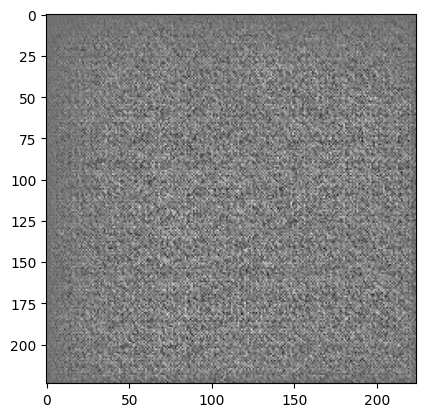

In [14]:
generator = make_generator_model()

noise = tf.random.normal([1, 100])
generated_image = generator(noise, training=False)

plt.imshow(generated_image[0, :, :, 0], cmap='gray')
#A grayscale image (224x224 pixels) displayed via matplotlib.

In [15]:
def make_discriminator_model():
    model = tf.keras.Sequential()
    
    # Input: 224x224x1 (matches generator output)
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=(224, 224, 1)))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Downsample to 112x112
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Downsample to 56x56
    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Downsample to 28x28
    model.add(layers.Conv2D(512, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Downsample to 14x14
    model.add(layers.Conv2D(1024, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    # Classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model

In [16]:
discriminator = make_discriminator_model()
decision = discriminator(generated_image)
print (decision)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


tf.Tensor([[-5.144076e-05]], shape=(1, 1), dtype=float32)


In [17]:
# InceptionV3 up to the avg-pool layer, to extract 2048-D features
fid_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299,299,3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
Params = {'batch_size': BATCH_SIZE}

In [ ]:
@tf.function
def get_fid_score(real_images, gen_images):
    """
    real_images, gen_images: float32 tensors in range [-1,1] and shape [N,224,224,1]
    will be resized to Inception’s 299×299 RGB input and fed into TF-GAN’s FID.
    """
    size = tfgan.eval.INCEPTION_DEFAULT_IMAGE_SIZE  # 299

    # 1) Bring pixel range to [0,255]
    real = (real_images * 127.5) + 127.5
    fake = (gen_images   * 127.5) + 127.5

    # 2) Resize to 299×299
    real_resized = tf.image.resize(real,  [size, size], method='bilinear')
    fake_resized = tf.image.resize(fake,  [size, size], method='bilinear')

    # 3) Convert to RGB by tiling the single channel
    real_rgb = tf.tile(real_resized, [1,1,1,3])
    fake_rgb = tf.tile(fake_resized, [1,1,1,3])

    # 4) Compute FID: TF-GAN expects num_batches = total_images ÷ batch_size
    num_batches = Params['batch_size'] // real_rgb.shape[0]
    fid = tfgan.eval.frechet_inception_distance(
        real_rgb, fake_rgb, num_batches=num_batches
    )
    return fid


In [18]:
# This method returns a helper function to compute cross entropy loss
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [19]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [20]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [21]:
generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

In [22]:
fid_history = []

In [31]:
# --- . Setup checkpointing ---
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir, "ckpt")
epoch_counter = tf.Variable(0, dtype=tf.int64)

checkpoint = tf.train.Checkpoint(
    epoch=epoch_counter,
    generator=generator,
    discriminator=discriminator,
    gen_opt=generator_optimizer,
    disc_opt=discriminator_optimizer
)
manager = tf.train.CheckpointManager(checkpoint, checkpoint_dir, max_to_keep=3)

# Restore the latest checkpoint if it exists
if manager.latest_checkpoint:
    checkpoint.restore(manager.latest_checkpoint)
    print(f"Restored from {manager.latest_checkpoint}, resuming at epoch {epoch_counter.numpy()}")
else:
    print("Starting training from scratch")

Restored from ./training_checkpoints/ckpt-50, resuming at epoch 50


In [24]:
def _prepare_for_inception(x):
    # x: float32 tensor in [-1,1], shape (N,224,224,1)
    x = (x * 127.5) + 127.5                       # → [0,255]
    x = tf.image.resize(x, (299,299))            # → 299×299
    x = tf.tile(x, [1,1,1,3])                     # gray → RGB
    return preprocess_input(x)                   # Inception preprocessing

def _frechet_distance(mu1, sigma1, mu2, sigma2, eps=1e-6):
    covmean, _ = linalg.sqrtm(sigma1.dot(sigma2), disp=False)
    if not np.isfinite(covmean).all():
        covmean = sigma1.dot(sigma2) + np.eye(sigma1.shape[0]) * eps
        covmean, _ = linalg.sqrtm(covmean, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return np.sum((mu1 - mu2)**2) + np.trace(sigma1 + sigma2 - 2*covmean)

def compute_fid(real_images, fake_images):
    # real_images & fake_images: float32 in [-1,1]
    act1 = fid_model(_prepare_for_inception(real_images)).numpy()
    act2 = fid_model(_prepare_for_inception(fake_images)).numpy()
    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    return _frechet_distance(mu1, sigma1, mu2, sigma2)


In [25]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 32

# You will reuse this seed overtime (so it's easier)
# to visualize progress in the animated GIF)
seed = tf.random.normal([num_examples_to_generate, noise_dim])

In [26]:
# Notice the use of `tf.function`
# This annotation causes the function to be "compiled".
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, noise_dim])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      generated_images = generator(noise, training=True)

      real_output = discriminator(images, training=True)
      fake_output = discriminator(generated_images, training=True)

      gen_loss = generator_loss(fake_output)
      disc_loss = discriminator_loss(real_output, fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

In [28]:
def train(dataset, epochs):
    for _ in range(epoch_counter.numpy(), epochs):
        start = time.time()
        current_epoch = epoch_counter.numpy() + 1

        # — 1. Training step —
        for image_batch in train_dataset:
            train_step(image_batch)

        # — 2. Save the same 32 preview images every epoch —
        display.clear_output(wait=True)
        generate_and_save_images(generator, current_epoch, seed)

        # — 3. Compute FID on those 32 images —
        N = seed.shape[0]  # 32
        # 3.1 Generate the same 32 fake images
        fake_images = generator(seed, training=False)

        # 3.2 Gather 32 real images
        real_batches = []
        for real_batch in train_dataset.take(int(np.ceil(N / BATCH_SIZE))):
            real_batches.append(real_batch)
        real_images = tf.concat(real_batches, axis=0)[:N]

        # 3.3 Compute FID
        fid_value = compute_fid(real_images, fake_images)

        # — Record FID in history —
        fid_history.append((current_epoch, float(fid_value)))

        # — 4. Print epoch summary including FID —
        elapsed = time.time() - start
        print(f"Epoch {current_epoch} completed in {elapsed:.2f}s — FID (32 imgs): {fid_value:.2f}")

        # — 5. Update and save checkpoint —
        epoch_counter.assign(current_epoch)
        manager.save()

    # — Final preview after the last epoch —
    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)


In [29]:
import math

def generate_and_save_images(model, epoch, test_input, cols=8):
    """
    Generates and saves a grid of images.
    - model: the generator
    - epoch: current epoch for filename
    - test_input: tensor of shape (N, noise_dim)
    - cols: number of columns in the grid
    """
    # 1) Generate images
    predictions = model(test_input, training=False)
    n = predictions.shape[0]

    # 2) Compute grid size
    rows = math.ceil(n / cols)

    # 3) Create figure
    fig = plt.figure(figsize=(cols, rows))

    # 4) Plot each image
    for i in range(n):
        ax = fig.add_subplot(rows, cols, i+1)
        img = predictions[i, :, :, 0] * 127.5 + 127.5  # rescale to [0,255]
        ax.imshow(img, cmap='gray')
        ax.axis('off')

    plt.tight_layout()

    # 5) Save and close
    plt.savefig(f'image_at_epoch_{epoch:04d}.png')
    plt.show()
    plt.close(fig)


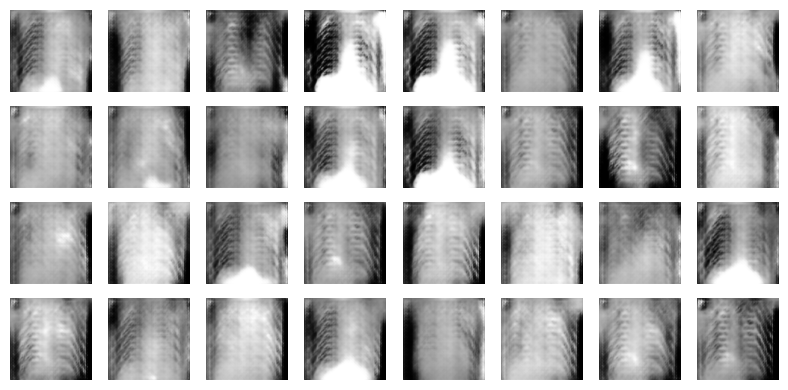

In [30]:
train(train_dataset, EPOCHS)

In [34]:
with open('fid_history.csv', 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(['epoch', 'fid'])
        writer.writerows(fid_history)
        print(f"Saved FID history to fid_history.csv")

Saved FID history to fid_history.csv


In [35]:
import zipfile

zip_path = 'generated_images.zip'
with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
    for filepath in glob.glob('image_at_epoch_*.png'):
        # add each png with just its basename inside the zip
        zf.write(filepath, arcname=os.path.basename(filepath))

print(f"Created {zip_path} with {len(zf.namelist())} images.")


Created generated_images.zip with 50 images.


In [ ]:
import shutil

# This will create 'generated_images.zip' containing everything in the 'generated_images' folder
shutil.make_archive('generated_images', 'zip', 'generated_images')


In [ ]:
# Display a single image using the epoch number
def display_image(epoch_no):
  return PIL.Image.open('image_at_epoch_{:04d}.png'.format(epoch_no))

In [ ]:
display_image(EPOCHS)

In [ ]:
anim_file = 'dcgan.gif'

with imageio.get_writer(anim_file, mode='I') as writer:
  filenames = glob.glob('image*.png')
  filenames = sorted(filenames)
  for filename in filenames:
    image = imageio.imread(filename)
    writer.append_data(image)
  image = imageio.imread(filename)
  writer.append_data(image)

In [ ]:
import tensorflow_docs.vis.embed as embed
embed.embed_file(anim_file)

In [ ]:
import shutil
from pathlib import Path

src = Path('/kaggle/input/tryfidmetric/resized')
dst = Path('/kaggle/working/')

#shutil.copy(src, dst)        # single file
# or for directories:
shutil.copytree('/kaggle/input/tryfidmetric/resized', '/kaggle/working/resized1')


In [ ]:
shutil.copytree('/kaggle/input/tryfidmetric/saved_examples-progan256/step6', '/kaggle/working/step6')